# Introduction

Welcome to demonstrations segment of UPXO. Let me help you get up and running and generate the first grain structure using UPXO and learn some basic details. It is highly recommended that you start from this Notebook.

- This notebook file: `..\src\upxo\demos\gschar\gschar1.ipynb`
- Author: SA

## About this demonstration 
This demonstration showcases the **UPXO Monte-Carlo Grain Structure (MCGS)** framework for generating and characterizing 2D polycrystalline microstructures. We will:

1. **Initialize** a Monte-Carlo grain growth simulation from an Excel configuration file
2. **Simulate** the grain structure evolution over discrete time steps
3. **Detect grains** in the grain structure
4. **Characterize** grain morphology (area, aspect ratio, solidity, etc.) at a specific temporal slice
5. **Visualize** the labeled grain structure and individual grain properties
6. **Extract** grain-specific data (pixel locations, bounding boxes) for detailed analysis

The workflow demonstrates UPXO's end-to-end pipeline from simulation setup through quantitative microstructure characterization, providing a foundation for statistical analysis, network topology studies, and finite element mesh generation.

## User input file

We will use the excel file `..\\src\\upxo\\demos\\gschar\\gschar1.xls` for this demonstration. The domain size is 50 x 50 with a pixel size of 1, number of Monte-Carlo states of 20 and a Monte-Carlo simulation time of 7 with unit time stepping. The time stepping cannot be controlled. `Note`: Please do not update rthis excel file!!

In [1]:
input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar1.xls'

## Import the mcgs module

In [2]:
from upxo.ggrowth.mcgs import mcgs

----

## Initialize the MC simulation

In [3]:
pxt = mcgs(input_dashboard=input_dashboard)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar1.xls
Algo_hops details
(('200.0', 100),)
[False]


* `pxt` is the Poly-XTAL object, which will be the absolute super-set storing all grain structure data in this demonstration. 
* We will now see how to retrieve three of its basic properties, the length, breadth and domain area

In [4]:
print(f"Simulation domain: {pxt.pxtal_length} x {pxt.pxtal_height} um: area = {pxt.pxtal_area} um^2")

Simulation domain: 50.0 x 50.0 um: area = 2500.0 um^2


---

## Simulate the grain growth

In [5]:
pxt.simulate()


 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|


* We can see the metadata neatly printed out above for your information
* GS stands for grain structure
* Temporal slice refers to a snapshot of the evolving grain structure.
* Temporal slice ID, i.e. grain structure temporal slice ID (i.e. `tslice`: a term you would encounter frequently in MCGS data in UPXO). Since we have used 7 `mcsteps` in the inpuit file, we see 7 GS temporal slices above. `NOTE`: if the number of the MC states reduces during simulation and becomes unity, then the grain structure evolution would stop at a tslice less than 7. However, this is possible for small `mcstate` values such as 3. Thids is unlikely in the present scenario as the number of states we have used is 20.
* ALG200 means the algorithm ID 200 selected in the input excel file (See `mcalg` in the input file.)

**NOTE**: The irst time you run would be slow, due to `numba` start up. Once cached, the subsequent calls must be quite fast. Try running the second time after clearing all outputs.

---

## Let us detect the grains in all temporal slices

In [6]:
pxt.detect_grains()

Using scikit-image for grain identification


In the above output, we see number of grains mentioned against the MC state value. This means that the grain structure is essentially partitioned into multiple sets, each set belonging to some state value and has a certain number of grains. For example, `MC state = 5:  Num grains = 4` would mean that there are 4 grains in the GS which belong to MC state value of 5. 

---

## Lets inspect the grain structure database

Temporal slices are stored in `pxt.gs`. It is a dictionary of 7 or less keys. We will not worry about the less than aspect at this stage, other than the case where the number of MC states redsuce to unity, as explained before. For now, its enough to know that you requested for 7 temporal slices and we see 7 elements in the dictionary. Please see the outputof the below cell.

In [7]:
pxt.gs

{0: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28420>,
 1: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28610>,
 2: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28800>,
 3: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e289f0>,
 4: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28be0>,
 5: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28dd0>,
 6: <upxo.pxtal.mcgs2_temporal_slice.mcgs2_grain_structure at 0x2c965e28fc0>}

Lets look at some of the metadata inside a database of ID = 3 (`gsid = 3`: grain strucure ID of 1)

In [12]:
tslice = 3
gstslice = pxt.gs[tslice]

we will use the gsid to address the grain sdtructure slice of interest, which is 3

In [13]:
print(f"Number of grains detected: {gstslice.n}\n", 20*'.  ' )
print(f"Temporal slice: {gstslice.m} \n", 20*'.  ' )
print(f"Pixel size: {gstslice.px_size} \n", 20*'.  ' )
print(f"User input grid data: {gstslice.uigrid} \n", 20*'.  ' )
print(f"Total number of MC States: {gstslice.S} \n", 20*'.  ' )

Number of grains detected: 156
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Temporal slice: 3 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Pixel size: 1.0 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
User input grid data: Attribues of gridding definitions: 
     TYPE: square
     DIMENSIONALITY: 2
     X: (0.0, 50.0, 1.0)
     Y: (0.0, 50.0, 1.0)
     Z: (0.0, 100.0, 1.0)
     PIXEL SIZE: 1.0
     TRANSFORMATION: none 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Total number of MC States: 20 
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  


You can access metadata inside `xt.gs[gsid].uigrid` as below:

In [14]:
print("User input grid data attributes:")
print(f"Dimensionality: {gstslice.uigrid.dim}\n", 20*'.  ' )
print(f"Max number of pixels: {gstslice.uigrid.npixels_max}\n", 20*'.  ' )
print(f"Type: {gstslice.uigrid.type}\n", 20*'.  ' )
print(f"X bound: {gstslice.uigrid.xbound}\n", 20*'.  ' )
print(f"Y bound: {gstslice.uigrid.ybound}\n", 20*'.  ' )
print(f"X min, Y min: {gstslice.uigrid.xmin}, {gstslice.uigrid.ymin}\n", 20*'.  ' )
print(f"X max, Y max: {gstslice.uigrid.xmax}, {gstslice.uigrid.ymax}\n", 20*'.  ' )
print(f"X increment, Y increment: {gstslice.uigrid.xinc}, {gstslice.uigrid.yinc}\n", 20*'.  ' )
print(f"X list, Y list: {gstslice.uigrid.xls}, \n\n{gstslice.uigrid.yls}\n", 20*'.  ' )
print(f"X Grid: {gstslice.uigrid.grid[0]}\n", 20*'.  ' )
print(f"Y Grid: {gstslice.uigrid.grid[1]}\n", 20*'.  ' )

User input grid data attributes:
Dimensionality: 2
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Max number of pixels: 250000
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Type: square
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
X bound: (0.0, 50.0, 1.0)
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
Y bound: (0.0, 50.0, 1.0)
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
X min, Y min: 0.0, 0.0
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
X max, Y max: 50.0, 50.0
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
X increment, Y increment: 1.0, 1.0
 .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  
X list, Y list: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.], 

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 

---

## Characterize the grain structure of interest

Dont worry too much about inputs other than the obvious grain morphological parameters. The ones with `True` value will be calculated. The decision to store is provided by the input `saa` (meaning `Store As Attribute`: the data will be stored inside `pxt.gs[gsid]` in easily retrievable format).

In [15]:
pxt.gs[tslice].char_morph_2d(use_version=2, bbox=True, bbox_ex=False, npixels=False,
                    identify_pixel_locations=True, npixels_gb=False,
                    area=True, aspect_ratio=True, solidity=True, 
                    major_axis_length=True, minor_axis_length=True,
                    circularity=False, eccentricity=False, euler_number=False,
                    moments_hu=False,
                    append=False, saa=True, throw=False, 
                    char_grain_positions=False, find_neigh=False, 
                    char_gb=False, make_skim_prop=True, 
                    get_grain_coords=True)

Characterising MC simulation time-slice 3
10.9%, 21.8%, 32.7%, 43.6%, 54.5%, 65.4%, 76.3%, 87.2%, 98.1%, 100.0%

Values indicates the percentage progress.

---

## Viewing the calculated properties.

In [16]:
pxt.gs[tslice].prop

,area,aspect_ratio,solidity,major_axis_length,minor_axis_length
0,9.0,1.390031,1.000000,3.885753,2.795443
1,49.0,1.347115,0.875000,9.434178,7.003244
2,95.0,2.635690,0.805085,18.778290,7.124620
3,1.0,1.000000,1.000000,1.000000,1.000000
4,29.0,1.323032,0.878788,7.139608,5.396398
...,...,...,...,...,...
151,9.0,2.081666,1.000000,4.807402,2.309401
152,12.0,1.377119,0.857143,4.756603,3.454024
153,12.0,1.442786,0.857143,4.760952,3.299832
154,24.0,1.852056,0.827586,7.815463,4.219885


Since we had earlier requested for area, aspect ratio, solidity and major and minor axis lengths, we can see them present in the above Pandas dataframe. The columns denote property names and the rows denote grain ID (`gid`). Note that the `gid` generally starts with 1 in `pxt.gs['gsid']` (as can be seen from `pxt.gs['gsid'].gid[0]`), however, please note that in the Pandas dataframe above, they start with 0, to ensure compatibility with further calculations employing packages such as NumPy.

In [17]:
print(f"First grain ID: {pxt.gs[tslice].gid[0]}")

First grain ID: 1


---

## Let's now see how the grain strucure looks like

In [18]:
import matplotlib.pyplot as plt

Above code imports the plotting library we will use to see the grain structure below.

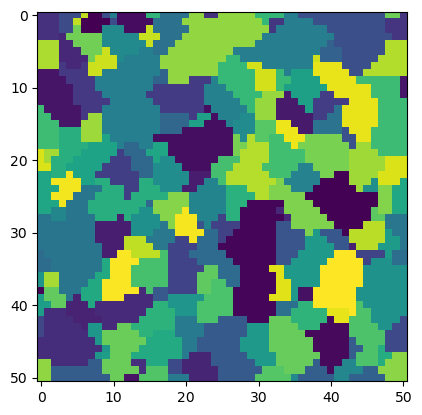

In [19]:
plt.imshow(pxt.gs[tslice].lgi)

The `lgi` in the above `pxt.gs[gsid].lgi` refers to local grain id. It is a N x M array of `gid` values mapped to each pixel.

---


### Access further data

In [20]:
print(f"Number of grains: {pxt.gs[tslice].n}")
print(f"Number of grains: {pxt.gs[tslice].calc_num_grains()}")
print(f"Grains belonging to slice {tslice} MC state {1}: {pxt.gs[tslice].s_gid[1]}")
print(f"MC State of the last grain ID: {pxt.gs[tslice].gid_s[pxt.gs[tslice].n-1]}")

Number of grains: 156
Number of grains: None
Grains belonging to slice 3 MC state 1: (1, 2, 3, 4, 5)
MC State of the last grain ID: 20


In [21]:
gstslice = pxt.gs[tslice]

***

### Accessing grains and grain data

In [23]:
fid = 1 # Feature ID, i.e. grain ID

print(f"The grain: {gstslice.g[fid]}")
print(f"Location (1st 2 for example..): {gstslice.g[fid].loc[:2]}")
print(f"Crentroid of feature: {gstslice.g[fid].centroid}")
print(f"Bounding Box: {gstslice.g[fid].bbox_bounds}")
print(f"Extended Bounding Box: {gstslice.g[fid].bbox_ex_bounds}")
print(f"SK Image property generator object: {gstslice.g[fid].skprop}")

The grain: <upxo.xtal.mcgrain2d_definitions.grain2d object at 0x000002C967B5CCC0>
Location (1st 2 for example..): [[0 7]
 [0 8]]
Crentroid of feature: (np.float16(7.332), np.float16(1.111))
Bounding Box: [0, 3, 6, 10]
Extended Bounding Box: [0, 4, 5, 11]
SK Image property generator object: <skimage.measure._regionprops.RegionProperties object at 0x000002C9664F70E0>


***

## Summary

This demonstration illustrated the fundamental UPXO workflow for 2D polycrystalline microstructure generation and characterization:

1. **Configuration-driven setup**: Excel dashboards (`input_dashboard.xls`) provide centralized control over grid parameters (50×50 μm domain), Monte-Carlo states (20), and simulation time (7 steps).

2. **Monte-Carlo grain growth**: The `mcgs.simulate()` method executes algorithm `200.0` to evolve grain structures through temporal slices (indexed by `tslice`/`gsid`). Simulation automatically terminates if the number of states reduces to unity.

3. **Grain detection**: `detect_grains()` uses connected component labeling to partition the state matrix into individual grains, grouped by Monte-Carlo state value (e.g., "MC state = 5: Num grains = 4").

4. **Data organization**: Each temporal slice (`pxt.gs[gsid]`) stores:
    - Metadata: grain count (`n`), pixel size (`px_size`), grid configuration (`uigrid`)
    - Labeled grain image (`lgi`): 2D array where each pixel value represents a grain ID
    - Grain properties (`prop`): Pandas DataFrame with per-grain metrics

5. **Morphological characterization**: `char_morph_2d()` computes grain properties (area, aspect ratio, solidity, etc.) with toggle flags. Setting `saa=True` stores results as attributes for further work; `identify_pixel_locations=True` enables per-grain pixel coordinate extraction.

6. **Property access patterns**: 
    - DataFrame indexing: `pxt.gs[gsid].prop` (0-indexed grain IDs for NumPy compatibility)
    - Grain ID list: `pxt.gs[gsid].gid` (1-indexed internal representation)
    - Grid metadata: `pxt.gs[gsid].uigrid.xls`, `pxt.gs[gsid].uigrid.grid[0]`

7. **Visualization**: `matplotlib.pyplot.imshow(pxt.gs[gsid].lgi)` renders the labeled grain structure with color-coded grain regions..

------- End of demonstration ---------

**Next notebook file to proceed with**: `..\src\upxo\demos\gschar\gschar2.ipynb`